In [9]:
import os
import pickle
import glob
import skimage
import skimage.transform
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from os import listdir
from os.path import isfile, join
import shutil, os
from scipy.signal import find_peaks

import sys

sys.path.append('../../functions')

import chirp_functions as proc
import stmpy

In [2]:
def return_sublat(origin, coord_crt, lat_vecs, sub_lat_vecs):
    "Enter the coordinates of the atomic site in the unit cell and the origin of the lattice (sublattice 1)."
    "Return the sublattice that the input coordinate belongs to."
    "Only works for triangle lattice."

    # Shift the coordinate to the origin
    rel_coord = np.array(coord_crt) - np.array(origin)

    # Express the relative coordinate in the basis of the lattice vectors
    A = np.column_stack(lat_vecs)
    try:
        coeffs = np.linalg.solve(A, rel_coord)
    except np.linalg.LinAlgError:
        # If the lattice vectors are not linearly independent
        return -2

    # Find the coordinate within the unit cell
    frac = coeffs - np.round(coeffs)
    cell_coord = np.dot(A, frac)

    # Compare to each sublattice vector
    for i, sub_vec in enumerate(sub_lat_vecs):
        if np.allclose(cell_coord, sub_vec, atol=1e-1):
            return i


    return -1

In [2]:
def return_sublat_triangle(origin, coord_crt, lat_vecs, sub_lat_vecs):
    "Enter the coordinates of the atomic site in the unit cell and the origin of the lattice (sublattice 1)."
    "Return the sublattice that the input coordinate belongs to."
    "Only works for triangle lattice. The first lattice vector is the horizontal one, the second is the non-horizontal one."

    # Shift the coordinate to the origin
    rel_coord = np.array(coord_crt) - np.array(origin)

    n2 = rel_coord[1] // lat_vecs[1][1]
    n1 = (rel_coord[0] - n2 * lat_vecs[1][0]) // lat_vecs[0][0]

    frac = rel_coord - n1 * lat_vecs[0] - n2 * lat_vecs[1]

    if np.allclose(frac, sub_lat_vecs[0], atol=1e-1):
        return 0
    elif np.allclose(frac, sub_lat_vecs[1], atol=1):
        return 1
    elif np.allclose(frac, sub_lat_vecs[2], atol=1):
        return 2
    else:
        return -1

In [4]:
x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4
lat_vecs = np.array([[4*x_unit, 0], [-2*x_unit, 2*y_unit]])
sub_lat_vecs = np.array([[-x_unit, y_unit], [0, 0], [x_unit, y_unit]])
coeffs = [0, 0]
coords = coeffs[0] * np.array(lat_vecs[0]) + coeffs[1] * np.array(lat_vecs[1]) + sub_lat_vecs[0]
a = return_sublat_triangle([0,0], coords, lat_vecs, sub_lat_vecs)
print(a)

-1


In [4]:
x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4
lat_vecs = np.array([[4*x_unit, 0], [2*x_unit, 2*y_unit]])
sub_lat_vecs = np.array([[4*x_unit, 0], [3*x_unit, y_unit], [x_unit, y_unit]])
coeffs = [0, 0]
coords = coeffs[0] * np.array(lat_vecs[0]) + coeffs[1] * np.array(lat_vecs[1]) + sub_lat_vecs[0]
a = return_sublat([0,0], coords, lat_vecs, sub_lat_vecs)
print(a)

NameError: name 'return_sublat' is not defined

# Preprocessing

In [2]:
# filter out cavities that are too far from the transducer
raw_dir = '../../../data/kagome-02.26.2022-center/raw/band_structure/'
dest_dir = '../../../data/kagome-02.26.2022-center/raw/band_structure_small/'
onlyfiles = [f for f in listdir(raw_dir) if (isfile(join(raw_dir, f)) and f != '.DS_Store')]

counter = 0


for fn in onlyfiles:
    x = float((fn.split('.')[0]).split('_')[-2])
    y = float((fn.split('.')[0]).split('_')[-1])

    x_unit = 10 * np.sqrt(3)/4
    y_unit = 10 * 3/4

    dist = np.sqrt((x*x_unit)**2 + (y*y_unit)**2)

    if dist <= 100:
        shutil.copy(raw_dir+fn, dest_dir)
        counter += 1

print('Raw files:', len(onlyfiles))
print('Copied', counter, 'files')




Raw files: 185
Copied 70 files


In [4]:
# preprocess
proc.preprocess_chirp(data_dir = raw_dir, 
                       frequencies = np.linspace(1000.0, 18000.0, 426), 
                       targetfile = '../../../data/kagome-02.26.2022-center/preprocessed_band/', 
                       title = 'scppos_', setno = 0)



Found 185 records
Preprocessing complete!


# Sublattice Fourier transform

In [18]:
folder = "../../../data/kagome-02.26.2022-center/"

freq = 7000.0

with open(folder + f"preprocessed_real/_{freq}_0.pkl",'rb') as f:
    real_data = pickle.load(f)

'''
Elements of real_data are assumed to look like:
    0: X in mm
    1: Y in mm
    2: Amplitude
    3: Phase in degrees
'''

sublat_1_data = []
sublat_2_data = []
sublat_3_data = []

lat_vecs = np.array([[4, 0], [2, 2]])
sub_lat_vecs = np.array([[0, 0], [1, 1], [3, 1]])

# Sort the real data into the 3 sublattices
for point in real_data:
    sub_lat = return_sublat_triangle(np.array([0,0]), np.array([point[0], point[1]]), lat_vecs, sub_lat_vecs)

    if sub_lat == 0:
        sublat_1_data.append(point)
    elif sub_lat == 1:
        sublat_2_data.append(point)
    elif sub_lat == 2:
        sublat_3_data.append(point)
    else:
        print('Error: point not in any sublattice', point[0], point[1])

L = 0.01
kxmax = 4*np.pi/(3*np.sqrt(3) * L)
kymax = 2*np.pi/(3*L)
kxs = np.linspace(-3*kxmax, 3*kxmax, 150)
kys = np.linspace(-3*kymax, 3*kymax, 150)

x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4

reciprocal_data_1 = np.zeros((len(kxs), len(kys)))
reciprocal_data_2 = np.zeros((len(kxs), len(kys)))
reciprocal_data_3 = np.zeros((len(kxs), len(kys)))
    
for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):
        reciprocal_data_1[yi][xi] = np.abs(np.array(
                [point[2] * np.exp(-1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in sublat_1_data]).sum())
        reciprocal_data_2[yi][xi] = np.abs(np.array(        
                [point[2] * np.exp(-1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in sublat_2_data]).sum())
        reciprocal_data_3[yi][xi] = np.abs(np.array(
                [point[2] * np.exp(-1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in sublat_3_data]).sum())

reciprocal_data = np.average([reciprocal_data_1, reciprocal_data_2, reciprocal_data_3], axis=0)


  0%|          | 0/150 [00:00<?, ?it/s]

In [13]:
import scipy.ndimage as snd
def sym2d(F, n):
        angle = 360.0/n
        out = np.zeros_like(F)
        for ix in range(n):
            out += snd.rotate(F, angle*ix, reshape=False)
            out += snd.rotate(F, -angle*ix, reshape=False)
        out /= 2*n
        return out

In [19]:
reciprocal_data_sym = stmpy.tools.symmetrize(reciprocal_data, 6, bp=(np.sqrt(3),1), diag=False)
#reciprocal_data_rot = sym2d(reciprocal_data, 6)

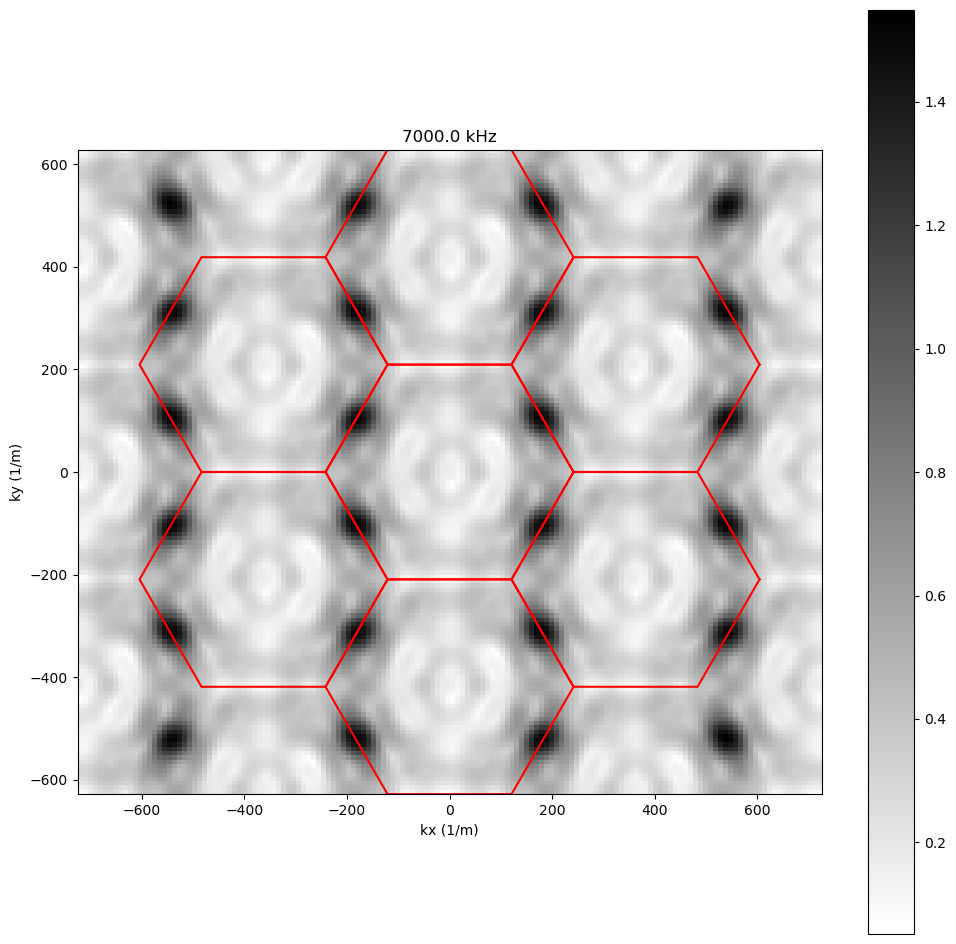

In [20]:

plt.figure(figsize=(12,12))
plt.imshow(reciprocal_data, cmap = 'binary', extent = [-3*kxmax, 3*kxmax, -3*kymax, 3*kymax], aspect = 'equal', origin = 'lower')

xBZ = np.zeros((7,7))
yBZ = np.zeros((7,7))

vec = np.array([[0,0], [np.sqrt(3), 1], [0, 2], [-np.sqrt(3),1], [-np.sqrt(3),-1], [0, -2], [np.sqrt(3),-1]])*kymax
xBZ[0] = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ[0] = [0, kymax, kymax, 0, -kymax, -kymax, 0]

for i in range(7):
    xBZ[i] = xBZ[0] + vec[i][0]
    yBZ[i] = yBZ[0] + vec[i][1]
    plt.plot(xBZ[i], yBZ[i], 'r-')


plt.xlabel("kx (1/m)")
plt.ylabel("ky (1/m)")
plt.title(str(freq)+" kHz")
plt.colorbar()

#plt.savefig(folder + "fourier/figures/2D_DFT_{}Hz.png".format(freq))
plt.show()

# 2D Fourier transform images

In [34]:
## 2D fourier transform new

folder = "../../../data/kagome-02.26.2022-center/"

freq = 7000.0

with open(folder + f"preprocessed_band/_{freq}_0.pkl",'rb') as f:
    real_data = pickle.load(f)

L = 0.01
kxmax = 4*np.pi/(3*np.sqrt(3) * L)
kymax = 2*np.pi/(3*L)
kxs = np.linspace(-3*kxmax, 3*kxmax, 150)
kys = np.linspace(-3*kymax, 3*kymax, 150)

reciprocal_data = np.zeros((len(kxs), len(kys)))
reciprocal_raw = np.zeros((len(kxs), len(kys)), dtype=complex)

x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4

    
'''
Elements of real_data are assumed to look like:
    0: X in mm
    1: Y in mm
    2: Amplitude
    3: Phase in degrees

'''
G = [[0.0, 0.0], [6*np.pi/(3*np.sqrt(3) * L), 2*np.pi/(3*L)], [6*np.pi/(3*np.sqrt(3) * L), -2*np.pi/(3*L)], [0, 4*np.pi/(3*L)]]

reciprocal_data = np.zeros((len(kxs), len(kys)))
reciprocal_raw = np.zeros((len(kxs), len(kys)), dtype=complex)

  
for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):            
            
        for k_no in range(4):
            k_current = [kxs[xi] + G[k_no][0], kys[yi] + G[k_no][1]]
            amplitude = np.abs(np.array(
                    [point[2] * np.exp(1j * (k_current[0] * (point[0]*x_unit/1000) + k_current[1] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                        for point in real_data]).sum())
            reciprocal_data[yi][xi] += amplitude
            

  0%|          | 0/150 [00:00<?, ?it/s]

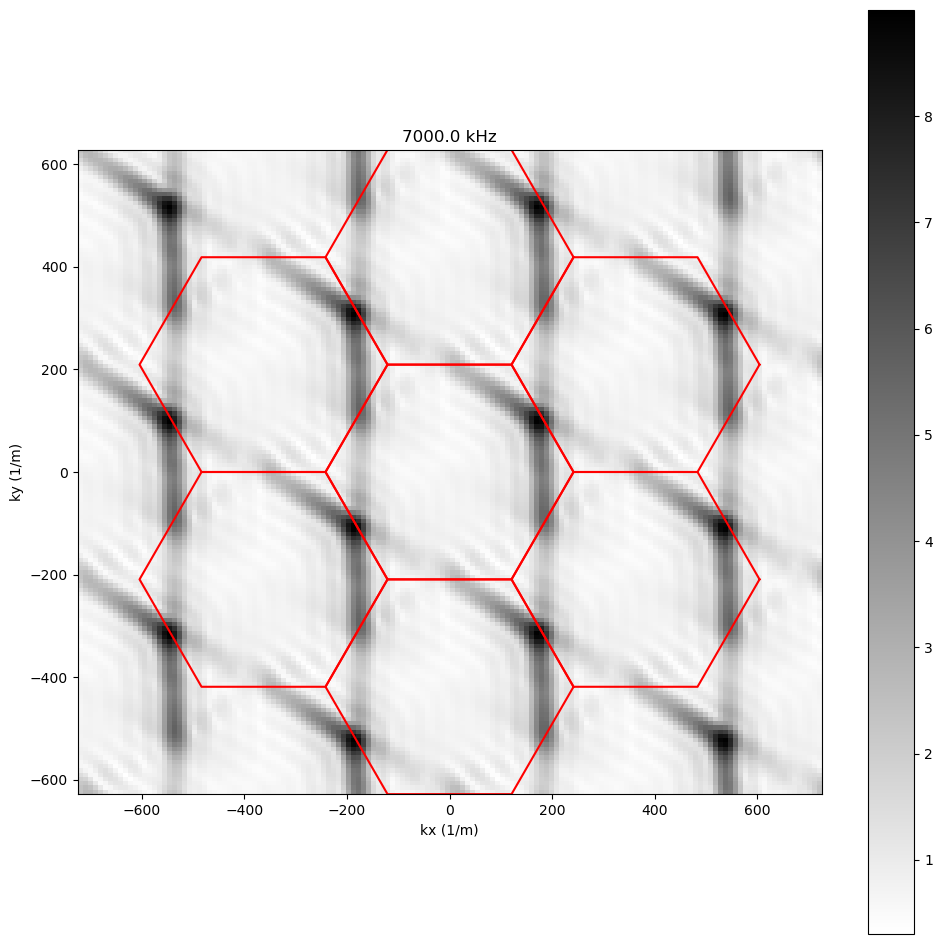

In [35]:

plt.figure(figsize=(12,12))
plt.imshow(reciprocal_data, cmap = 'binary', extent = [-3*kxmax, 3*kxmax, -3*kymax, 3*kymax], aspect = 'equal', origin = 'lower')

xBZ = np.zeros((7,7))
yBZ = np.zeros((7,7))

vec = np.array([[0,0], [np.sqrt(3), 1], [0, 2], [-np.sqrt(3),1], [-np.sqrt(3),-1], [0, -2], [np.sqrt(3),-1]])*kymax
xBZ[0] = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ[0] = [0, kymax, kymax, 0, -kymax, -kymax, 0]

for i in range(7):
    xBZ[i] = xBZ[0] + vec[i][0]
    yBZ[i] = yBZ[0] + vec[i][1]
    plt.plot(xBZ[i], yBZ[i], 'r-')


plt.xlabel("kx (1/m)")
plt.ylabel("ky (1/m)")
plt.title(str(freq)+" kHz")
plt.colorbar()

plt.savefig(folder + "fourier/figures/2D_DFT_{}Hz.png".format(freq))
plt.show()



# 2D Fourier transform simple

In [79]:
## 2D fourier transform new

folder = "../../../data/kagome-02.26.2022-center/"

freq = 14200.0

with open(folder + f"preprocessed_band/_{freq}_0.pkl",'rb') as f:
    real_data = pickle.load(f)

L = 0.01
kxmax = 4*np.pi/(3*np.sqrt(3) * L)
kymax = 2*np.pi/(3*L)
kxs = np.linspace(-3*kxmax, 3*kxmax, 150)
kys = np.linspace(-3*kymax, 3*kymax, 150)

reciprocal_data = np.zeros((len(kxs), len(kys)))
reciprocal_raw = np.zeros((len(kxs), len(kys)), dtype=complex)

x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4

    
'''
Elements of real_data are assumed to look like:
    0: X in mm
    1: Y in mm
    2: Amplitude
    3: Phase in degrees

'''

reciprocal_data = np.zeros((len(kxs), len(kys)))
reciprocal_raw = np.zeros((len(kxs), len(kys)), dtype=complex)

  
for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):            
        amplitude = np.abs(np.array(
                [point[2] * np.exp(1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in real_data]).sum())
        reciprocal_data[yi][xi] += amplitude
            

  0%|          | 0/150 [00:00<?, ?it/s]

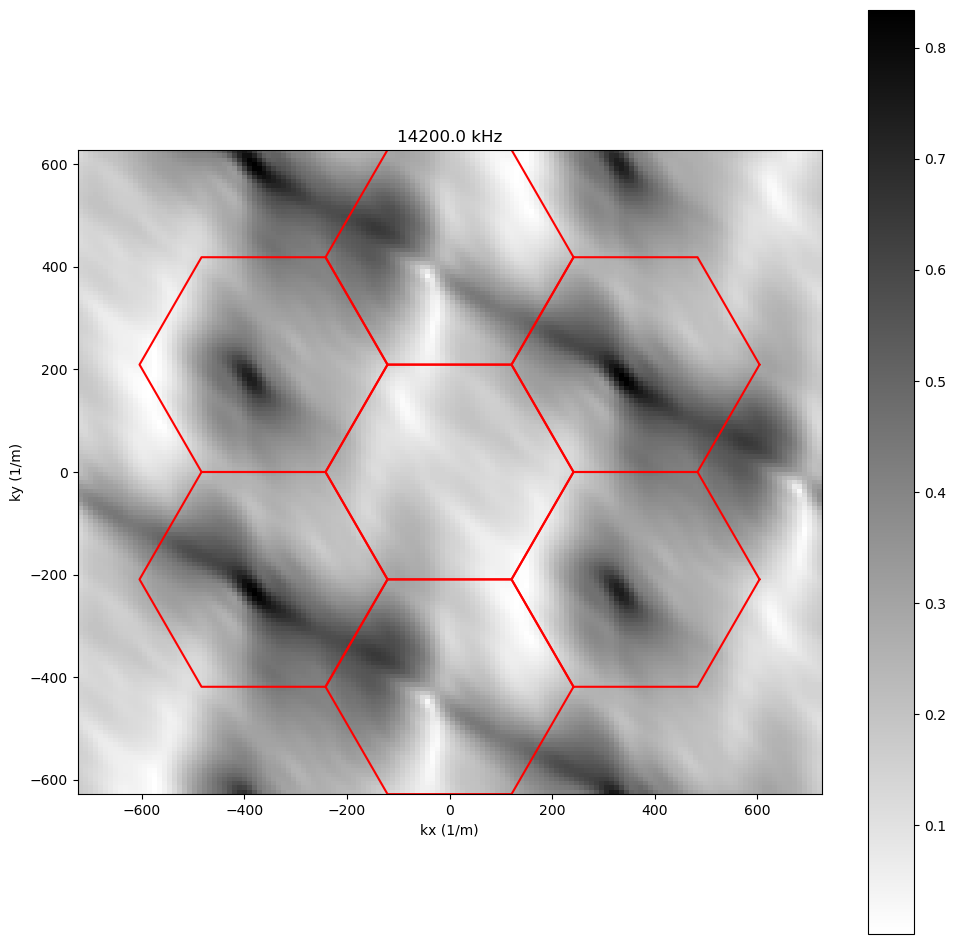

In [80]:

plt.figure(figsize=(12,12))
plt.imshow(reciprocal_data, cmap = 'binary', extent = [-3*kxmax, 3*kxmax, -3*kymax, 3*kymax], aspect = 'equal', origin = 'lower')

xBZ = np.zeros((7,7))
yBZ = np.zeros((7,7))

vec = np.array([[0,0], [np.sqrt(3), 1], [0, 2], [-np.sqrt(3),1], [-np.sqrt(3),-1], [0, -2], [np.sqrt(3),-1]])*kymax
xBZ[0] = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ[0] = [0, kymax, kymax, 0, -kymax, -kymax, 0]

for i in range(7):
    xBZ[i] = xBZ[0] + vec[i][0]
    yBZ[i] = yBZ[0] + vec[i][1]
    plt.plot(xBZ[i], yBZ[i], 'r-')


plt.xlabel("kx (1/m)")
plt.ylabel("ky (1/m)")
plt.title(str(freq)+" kHz")
plt.colorbar()

plt.savefig(folder + "fourier/figures/2D_DFT_{}Hz.png".format(freq))
plt.show()



# Sweep visualization

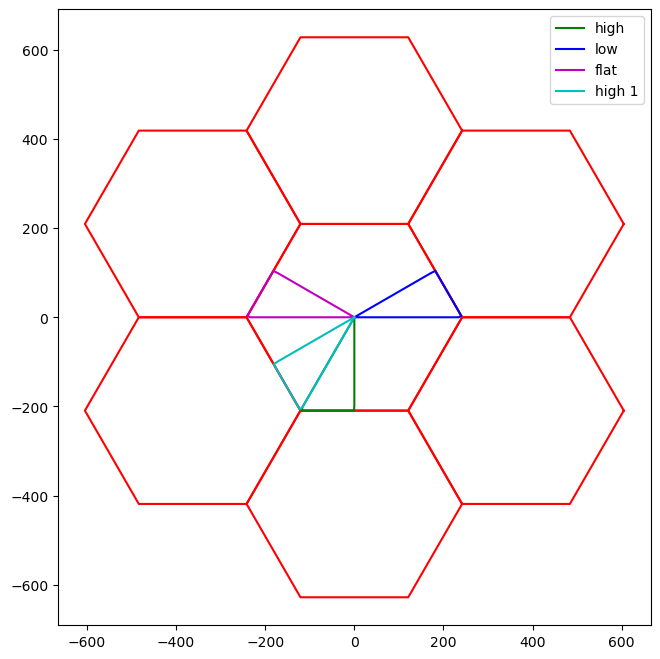

In [5]:
# visualizing the 3 sweeps in reciprocal space

from tqdm.notebook import tqdm
import csv


#freqs = np.array([(0, np.array(list(np.linspace(1,16,76))+list(np.linspace(16,17, 51))+list(np.linspace(17,18,6))))], dtype=object)
freq_num = 426
freq_min = 1000.0
freq_max = 18000.0
freqs = np.array([(0, np.linspace(freq_min, freq_max, freq_num))], dtype=object)

freq_div1 = 9000
freq_div2 = 13600

#L_kag = 0.008
#L = L_kag*np.sqrt(3)/2*(np.sqrt(3)+1)
L = 0.01
kxmax = 4*np.pi/(3*np.sqrt(3) * L)
kymax = 2*np.pi/(3*L)

b_res = 50
b = np.linspace(0, 1.5+np.sqrt(3)/2, b_res) #GKMG sweep parameter

kxb_low = np.zeros(len(b))
kyb_low = np.zeros(len(b))
kxb_high = np.zeros(len(b))
kyb_high = np.zeros(len(b))
kxb_flat = np.zeros(len(b))
kyb_flat = np.zeros(len(b))
kxb_high_1 = np.zeros(len(b))
kyb_high_1 = np.zeros(len(b))

for i in range(len(b)):
    if b[i] < 1:   
        
        kxb_low[i] = 4 * np.pi / (3 * np.sqrt(3) * L) * b[i]
        kyb_low[i] = 0
        kxb_high[i] = -b[i] * 2 * np.pi / (np.sqrt(3)*3 * L) 
        kyb_high[i] = - b[i] * 2 * np.pi / (3 * L)
        kxb_high_1[i] = -b[i] * 2 * np.pi / (np.sqrt(3)*3 * L) 
        kyb_high_1[i] = - b[i] * 2 * np.pi / (3 * L)
        kxb_flat[i] = -4 * np.pi / (3 * np.sqrt(3) * L) * b[i]
        kyb_flat[i] = 0
        
    elif b[i] < 1.5: 
        kxb_low[i] = 4 * np.pi / (3 * np.sqrt(3) * L) - 2 * np.pi / (3 * np.sqrt(3) * L) * (b[i]-1)
        kyb_low[i] = 2 * np.pi / (3 * L) * (b[i]-1)
        kxb_high[i] = -2 * np.pi / (np.sqrt(3)*3 * L) + 2 * 2 * np.pi / (3 * np.sqrt(3) * L) * (b[i]-1)
        kyb_high[i] = -2 * np.pi / (3 * L) 
        kxb_high_1[i] = 4 * np.pi / (3 * np.sqrt(3) * L) - 2 * np.pi / (3 * np.sqrt(3) * L) * (b[i]-1)-3/2*kxmax
        kyb_high_1[i] = 2 * np.pi / (3 * L) * (b[i]-1) - kymax
        kxb_flat[i] = -(4 * np.pi / (3 * np.sqrt(3) * L) - 2 * np.pi / (3 * np.sqrt(3) * L) * (b[i]-1))
        kyb_flat[i] = 2 * np.pi / (3 * L) * (b[i]-1)
    else:

        kxb_low[i] = (1- (b[i] - 1.5) * 2 / np.sqrt(3)) * np.pi / (np.sqrt(3) * L)
        kyb_low[i] = (1- 2 / (np.sqrt(3)) * (b[i]-1.5)) * np.pi / (3 * L)
        kxb_high[i] = 0
        kyb_high[i] = -2 * np.pi / (3 * L) + 2 * np.pi / (3 * L) *2 / np.sqrt(3) * (b[i]-1.5)
        kxb_high_1[i] = -(1- (b[i] - 1.5) * 2 / np.sqrt(3)) * np.pi / (np.sqrt(3) * L)
        kyb_high_1[i] = -(1- 2 / (np.sqrt(3)) * (b[i]-1.5)) * np.pi / (3 * L) 
        kxb_flat[i] = -(1- (b[i] - 1.5) * 2 / np.sqrt(3)) * np.pi / (np.sqrt(3) * L)
        kyb_flat[i] = (1- 2 / (np.sqrt(3)) * (b[i]-1.5)) * np.pi / (3 * L)
        
        
        



plt.figure(figsize=(8,8))


xBZ = np.zeros((7,7))
yBZ = np.zeros((7,7))

vec = np.array([[0,0], [np.sqrt(3), 1], [0, 2], [-np.sqrt(3),1], [-np.sqrt(3),-1], [0, -2], [np.sqrt(3),-1]])*kymax
xBZ[0] = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ[0] = [0, kymax, kymax, 0, -kymax, -kymax, 0]


for i in range(7):
    xBZ[i] = xBZ[0] + vec[i][0]
    yBZ[i] = yBZ[0] + vec[i][1]
    plt.plot(xBZ[i], yBZ[i], 'r-')


plt.plot(kxb_high, kyb_high, 'g-',label='high')
plt.plot(kxb_low, kyb_low, 'b-',label='low')
plt.plot(kxb_flat, kyb_flat, 'm-',label='flat')
plt.plot(kxb_high_1, kyb_high_1, 'c-',label='high 1')
plt.legend()
ax = plt.gca()
ax.set_aspect('equal')


# Fourier transform


Shift the Fourier transformed function in reciprocal space by 4 different reciprocal lattice vectors and summed them up to make sure the key features stay within the first Brillouin zone. 

In [6]:
filename = '../../../data/kagome-02.26.2022-center/preprocessed_band/'

reciprocal_data = np.zeros((freq_num, b_res))
x_unit = 10*np.sqrt(3)/4/1000
y_unit = 7.5/1000

G = [[0.0, 0.0], [6*np.pi/(3*np.sqrt(3) * L), 2*np.pi/(3*L)], [6*np.pi/(3*np.sqrt(3) * L), -2*np.pi/(3*L)], [0, 4*np.pi/(3*L)]]
    
for setno, values in freqs:
    for j in tqdm(range(len(values))):
        with open(filename + '_' + str(values[j]) + '_' + str(setno) + '.pkl','rb') as f:
            real_data = pickle.load(f) 
            
            if values[j] <= freq_div1:
                
                for i in range(b_res):
                    for k_no in range(4):
                        k_current = [kxb_low[i] + G[k_no][0], kyb_low[i] + G[k_no][1]]
                        amplitude = np.abs(np.array(
                                [point[2] * np.exp(1j * (k_current[0] * (point[0]*x_unit) + k_current[1] * (point[1]*y_unit) + (point[3] / 57.2957795131))) 
                                    for point in real_data]).sum())
                        reciprocal_data[j][i] += amplitude
                        
            else:
                for i in range(b_res):
                    for k_no in range(4):
                        k_current = [kxb_high[i] + G[k_no][0], kyb_high[i] + G[k_no][1]]
                        amplitude = np.abs(np.array(
                                [point[2] * np.exp(1j * (k_current[0] * (point[0]*x_unit) + k_current[1] * (point[1]*y_unit) + (point[3] / 57.2957795131))) 
                                    for point in real_data]).sum())
                        reciprocal_data[j][i] += amplitude
 

  0%|          | 0/426 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '../../../paper/figure2/band-structure.pdf'

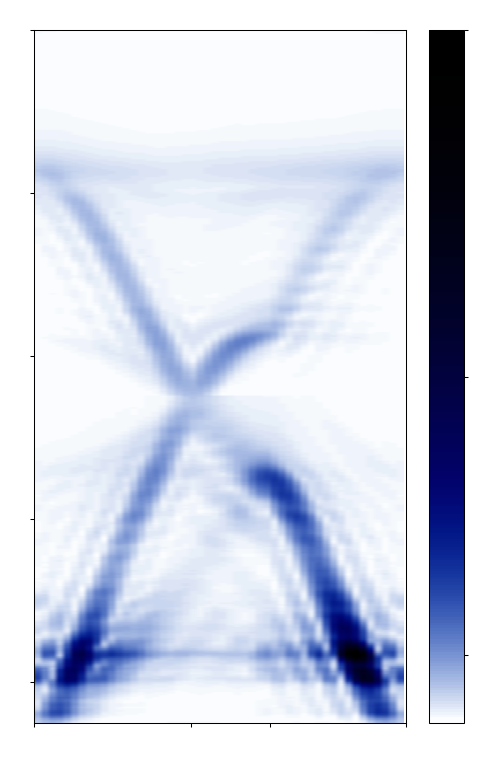

In [7]:
#print(np.max(reciprocal_data_plot))

#reciprocal_data_plot = (reciprocal_data-np.min(reciprocal_data))/(np.max(reciprocal_data)-reciprocal_data)
reciprocal_data_plot = reciprocal_data/np.max(reciprocal_data)


from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
import matplotlib.cm as cm


folder = '../../../data/kagome-02.26.2022-center/'

b_sim = []
band1 = []
band2 = []
band3 = []



with open('../../../data/simulation/kagome_machine_bands_clean.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    for row in reader:
        b_sim.append(float(row[0]))
        band1.append(float(row[1]))
        band2.append(float(row[2]))
        band3.append(float(row[3]))

K = np.sqrt(1+1/3)
M = K + 1/np.sqrt(3)
G = M + 1
extent = [0, G, 1, 18]

# GKMG sweep
plt.figure(figsize = (2, 3), dpi = 300)

plt.imshow(reciprocal_data_plot, extent=[b[0], b_sim[-1], 1, 18], aspect='auto', origin='lower', cmap=stmpy.cm.blue3_r)

#plt.plot(b_sim, band1, linestyle = '-', color = "r", linewidth = 0.5, alpha=0.5)
#plt.plot(b_sim, band2, linestyle = '-', color = "r", linewidth = 0.5, alpha=0.5)
#plt.plot(b_sim, band3, linestyle = '-', color = "r", linewidth = 0.5, alpha=0.5)
plt.axis([b[0], b[-1], 1, 18])
cb = plt.colorbar(ticks = [0.1, 0.5, 1])
cb.ax.set_yticklabels(['','',''])
cb.ax.yaxis.set_tick_params(width=0.25, length = 1)
plt.yticks(np.linspace(2, 18, 5), fontsize = 20)



plt.xticks([0, 1, 1.5, b[-1]], fontsize=25)
ax = plt.gca()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)

ax.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)
cb.outline.set_linewidth(0.25)

ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)
plt.savefig('../../../paper/figure2/band-structure.pdf')



In [ ]:
print(G, b_sim[-1])

2.732050807568877 2.35


In [ ]:
# Save data with numpy savetxt

np.savetxt('../../../data/kagome-02.26.2022-center/fourier/band_heatmap.txt', reciprocal_data_plot, delimiter=',')

# Fourier transform new algorithm

In [6]:
def mirror_point(pt_coord, line_slope):
    x0 = pt_coord[0]
    y0 = pt_coord[1]

    # first find the angle between the point and the line
    angle = np.arctan2(line_slope, 1) - np.arctan2(y0, x0)

    # then find the mirrored point by rotating (x0, y0) by 2 times the angle
    x1 = x0 * np.cos(2*angle) - y0 * np.sin(2*angle)
    y1 = x0 * np.sin(2*angle) + y0 * np.cos(2*angle)

    return x1, y1

In [7]:
x1, y1 = mirror_point((0,0.5), 1)
print(f'Mirrored point: ({x1}, {y1})')

Mirrored point: (0.5, 3.061616997868383e-17)


In [8]:
filename = "../../../data/kagome-02.26.2022-center/preprocessed_band/"

sublat_1_data = []
sublat_2_data = []
sublat_3_data = []

# lat_vecs = [[4*x_unit, 0], [2*x_unit, 2*y_unit]]
# sub_lat_vecs = [[0, 0], [x_unit, y_unit], [x_unit*3, y_unit]]

lat_vecs = np.array([[4, 0], [2, 2]])
sub_lat_vecs = np.array([[0, 0], [1, 1], [3, 1]])

x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4

reciprocal_data_1 = np.zeros((freq_num, b_res))
reciprocal_data_2 = np.zeros((freq_num, b_res))
reciprocal_data_3 = np.zeros((freq_num, b_res))

rot_angles = np.linspace(0, 360, 6, endpoint=False) * np.pi / 180

for setno, values in freqs:
    for i in tqdm(range(len(values))):
        
        with open(filename + '_' + str(values[i]) + '_' + str(setno) + '.pkl','rb') as f:
            real_data = pickle.load(f) 
            # Clear sublattice lists for each iteration
            sublat_1_data = []
            sublat_2_data = []
            sublat_3_data = []

            # Sort the real data into the 3 sublattices
            for point in real_data:
                sub_lat = return_sublat_triangle([0,0], np.array([point[0], point[1]]), lat_vecs, sub_lat_vecs)

                if sub_lat == 0:
                    sublat_1_data.append(point)
                elif sub_lat == 1:
                    sublat_2_data.append(point)
                elif sub_lat == 2:
                    sublat_3_data.append(point)
    
            for j in range(b_res):
                kxb = kxb_low[j]
                kyb = kyb_low[j]

                # mirror the point (kxb, kyb) about the line y=1/sqrt(3)*x to get kxb_mirr and kyb_mirr
                kxb_mirr, kyb_mirr = mirror_point((kxb, kyb), 1/np.sqrt(3))

                reciprocal_data_1[i][j] = 0
                reciprocal_data_2[i][j] = 0
                reciprocal_data_3[i][j] = 0

                for k in range(len(rot_angles)):
                    kxb_crt = kxb * np.cos(rot_angles[k]) - kyb * np.sin(rot_angles[k])
                    kyb_crt = kxb * np.sin(rot_angles[k]) + kyb * np.cos(rot_angles[k])
                    kxb_mirr_crt = kxb_mirr * np.cos(rot_angles[k]) - kyb_mirr * np.sin(rot_angles[k])
                    kyb_mirr_crt = kxb_mirr * np.sin(rot_angles[k]) + kyb_mirr * np.cos(rot_angles[k])

                    reciprocal_data_1[i][j] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_crt * (point[0]*x_unit/1000) + kyb_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                                    for point in sublat_1_data]).sum())
                    reciprocal_data_1[i][j] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_mirr_crt * (point[0]*x_unit/1000) + kyb_mirr_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                                    for point in sublat_1_data]).sum())
                    reciprocal_data_2[i][j] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_crt * (point[0]*x_unit/1000) + kyb_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                                    for point in sublat_2_data]).sum())
                    reciprocal_data_2[i][j] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_mirr_crt * (point[0]*x_unit/1000) + kyb_mirr_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                                    for point in sublat_2_data]).sum())
                    reciprocal_data_3[i][j] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_crt * (point[0]*x_unit/1000) + kyb_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                                    for point in sublat_3_data]).sum())
                    reciprocal_data_3[i][j] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_mirr_crt * (point[0]*x_unit/1000) + kyb_mirr_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                                    for point in sublat_3_data]).sum())

                reciprocal_data_1[i][j] /= len(rot_angles)*2
                reciprocal_data_2[i][j] /= len(rot_angles)*2
                reciprocal_data_3[i][j] /= len(rot_angles)*2

reciprocal_data = np.average([reciprocal_data_1, reciprocal_data_2, reciprocal_data_3], axis=0)

  0%|          | 0/426 [00:00<?, ?it/s]

In [10]:
kxb_low[0]

np.float64(0.0)

In [11]:
reciprocal_data.shape

(426, 50)

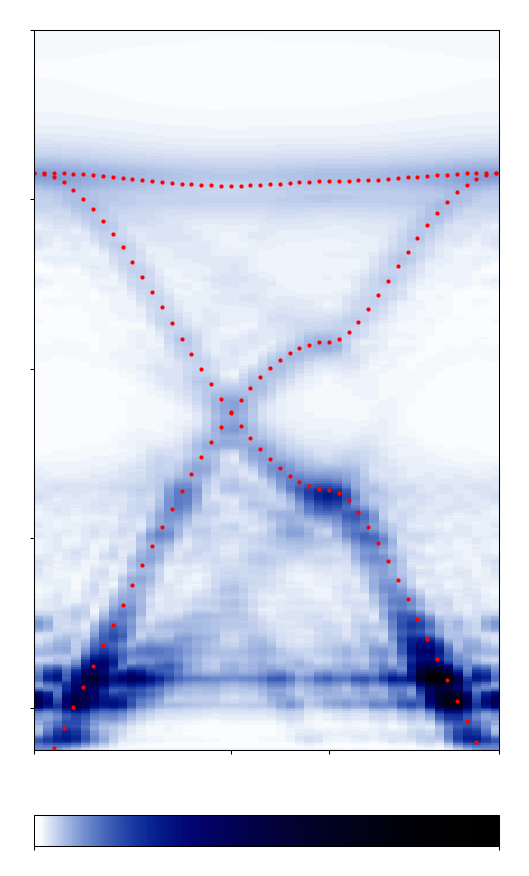

In [16]:

reciprocal_data_plot = reciprocal_data/np.max(reciprocal_data)


from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
import matplotlib.cm as cm


folder = '../../../data/kagome-02.26.2022-center/'

b_sim = []
band1 = []
band2 = []
band3 = []



with open('../../../data/simulation/kagome_machine_bands_clean.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    for row in reader:
        b_sim.append(float(row[0]))
        band1.append(float(row[1]))
        band2.append(float(row[2]))
        band3.append(float(row[3]))


# GKMG sweep
fig, ax = plt.subplots(figsize = (2, 4), dpi = 300)
freq = np.linspace(1000.0, 18000.0, 426)
min_index = np.where(freq == 1000.0)[0][0]
max_index = len(reciprocal_data)
b_mesh, freq_mesh = np.meshgrid(b, freq / 1000)
plt.imshow(
    reciprocal_data_plot,
    extent=[b[0], b[-1], 1, 18],
    origin='lower',
    aspect='auto',
    interpolation='none',
    cmap=stmpy.cm.blue3_r
)
ax.plot(b_sim, band1, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)
ax.plot(b_sim, band2, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)
ax.plot(b_sim, band3, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)
ax.axis([b[0], b[-1], 1, 18])
#cb = stmpy.image.add_cbar(ax=ax, fs=6.5, length='25%', sf=1, pad=0.07, labelpad=0.03)
cb = plt.colorbar(ticks = [0,1], location='bottom', pad=0.07, aspect=15)
# set the length of the colorbar to be 50% of the axis length
cb.set_ticks([0, 1], labels=['', ''])
cb.ax.tick_params(labelsize=6.5)
cb.ax.xaxis.set_tick_params(width=0.25, length = 1)
cb.outline.set_linewidth(0.25)
ax.set_yticks(np.linspace(2, 18, 5))
ax.set_xticks([0, 1, 1.5, b[-1]])

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)

ax.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)


ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)
fig.savefig('../../../output/paper_new/band_fig/band_structure_sublat_algorithm.pdf')



(0.0, 0.3)

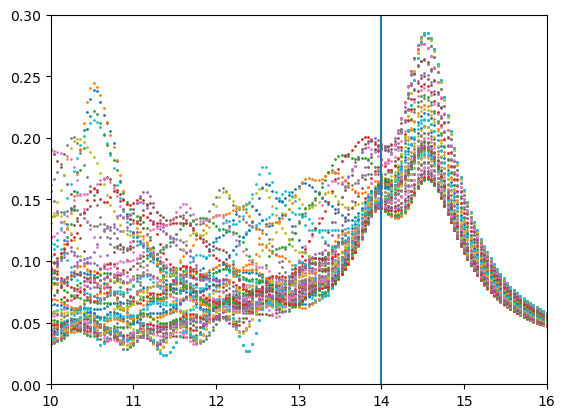

In [27]:
# Make a vertical cut at each b value and find the frequency at which the reciprocal_data is maximum for frequencies above 13.5 kHz

for i in range(b_res):
    plt.scatter(freq/1e3, reciprocal_data[:, i], s=1)
    

plt.axvline(14)
plt.xlim(10,16)
plt.ylim(0, 0.3)

In [37]:
# Make a vertical cut at each b value and find the frequency at which the reciprocal_data is maximum for frequencies above 13.5 kHz

flat_freq_cut = np.argmin(np.abs(freq - 14e3))
reciprocal_data_flat = reciprocal_data[flat_freq_cut:, :]

fb_peaks = np.zeros(b_res)
fb_max = freq[np.argmax(reciprocal_data_flat, axis=0) + flat_freq_cut]

for i in range(b_res):
    fb_peaks[i] = freq[find_peaks(reciprocal_data_flat[:, i], height=0.05)[0][-1] + flat_freq_cut]

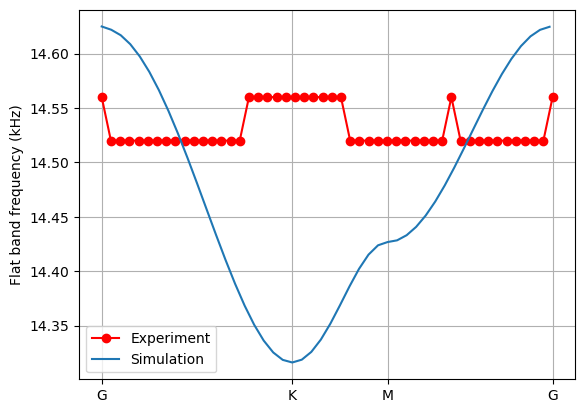

In [93]:
#plt.plot(b, fb_peaks/1e3, 'ko-')
plt.plot(b, fb_max/1e3, 'ro-', label='Experiment')
plt.plot(b_sim, band1, label='Simulation')
plt.xticks([0, 1, 1.5, b[-1]], ['G', 'K', 'M', 'G'])
plt.ylabel('Flat band frequency (kHz)')
plt.grid()
plt.legend()

Experimental 21.52 m/s
Estimate from max freq - min freq: 2.08 m/s


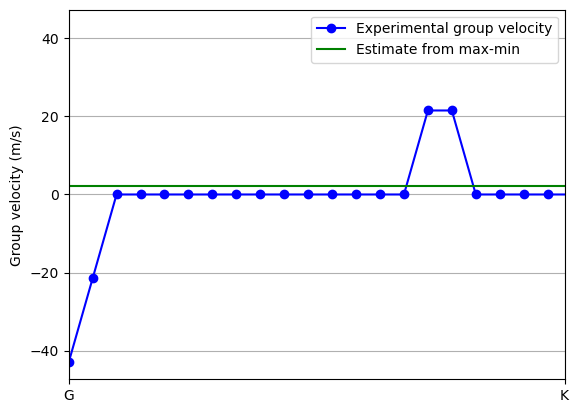

In [90]:
vg_exp = 2*np.pi * np.gradient(fb_peaks) / (np.gradient(b) * kxmax/2)
vg_exp_avg = 2*np.pi * (np.max(fb_peaks) - np.min(fb_peaks)) / (kxmax/2)
plt.plot(b, vg_exp, 'bo-', label='Experimental group velocity')
plt.axhline(vg_exp_avg, color='g', label='Estimate from max-min')
plt.ylabel('Group velocity (m/s)')
plt.xticks([0, 1], ['G', 'K'])
plt.xlim(0, 1)
plt.legend()
plt.grid()
print('Experimental {:.2f} m/s'.format(np.max(vg_exp[:21])))
print('Estimate from max freq - min freq: {:.2f} m/s'.format(vg_exp_avg))

Simulation -24.71 m/s
Estimate from max freq - min freq: -16.05 m/s


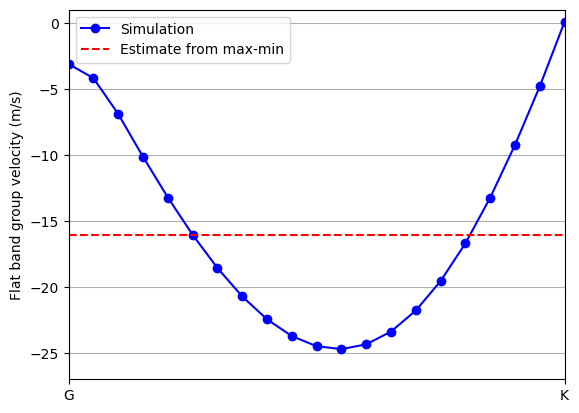

In [87]:
# Calculate the flat band group velocity in G-K interval from simulation


vg_fb = 2*np.pi * np.gradient(band1*1e3) / (np.gradient(np.array(b_sim)*kxmax/2))
v_estimate = 2*np.pi * (np.max(band1) - np.min(band1))*1e3 / (kxmax/2)

plt.plot(b_sim, vg_fb, 'bo-', label='Simulation')
plt.axhline(-v_estimate, color='r', linestyle='--', label='Estimate from max-min')
plt.xlim(0,1)
plt.ylim(-27, 1)
plt.xticks([0, 1], ['G', 'K'])
plt.ylabel('Flat band group velocity (m/s)')
plt.legend()
plt.grid()

print('Simulation {:.2f} m/s'.format(np.min(vg_fb)))
print('Estimate from max freq - min freq: {:.2f} m/s'.format(-v_estimate))


In [66]:
from scipy.optimize import curve_fit

def gaussian(x, a, b, c, d):
    return a * np.exp(-((x - b) ** 2) / (2 * c ** 2)) + d

[0.18025706 0.52026844 0.06072289 0.08853268] [0.2281497  1.80478778 0.07425863 0.07862442]
[0.07271239 0.54529459 0.06304869 0.0680144 ] [0.09460012 1.79168438 0.09059456 0.05883477]


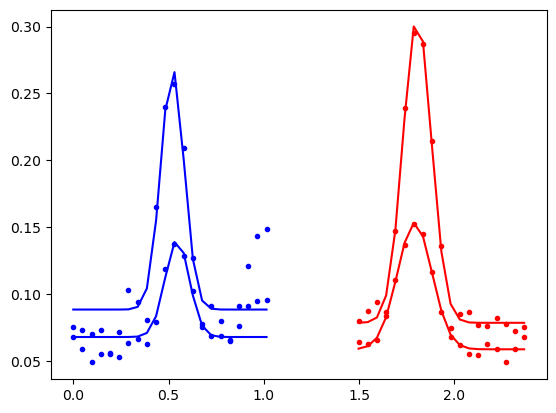

In [78]:
# Fit for k space resolution at 5kHz and 12 kHz

freq_fit = np.array([5, 12])*1e3
b_axis = np.linspace(0, 1.5+np.sqrt(3)/2, reciprocal_data.shape[1])
k_pt_idx = np.argmin(np.abs(b_axis - 1))
m_pt_idx = np.argmin(np.abs(b_axis - 1.5))

for freq_crt in freq_fit:
    freq_idx = np.where(np.isclose(freq, freq_crt, atol=1e-2))[0]
    intensity_cut = reciprocal_data[freq_idx, :].T

    gamma_K_cut = intensity_cut[:k_pt_idx+1].flatten()
    gamma_M_cut = intensity_cut[m_pt_idx:].flatten()
    b_axis_K_cut = b_axis[0:k_pt_idx+1]
    b_axis_M_cut = b_axis[m_pt_idx:]


    # Fit a Gaussian to the K point cut and M point cut separately
    peak_K_idx = np.argmax(gamma_K_cut)
    peak_M_idx = np.argmax(gamma_M_cut)
    popt_K, pcov_K = curve_fit(gaussian, b_axis_K_cut, gamma_K_cut, p0=[1, b_axis_K_cut[peak_K_idx], 0.1, 0])
    popt_M, pcov_M = curve_fit(gaussian, b_axis_M_cut, gamma_M_cut, p0=[1, b_axis_M_cut[peak_M_idx], 0.1, 0])

    print(popt_K, popt_M)

    plt.plot(b_axis_K_cut, gamma_K_cut, 'b.', label='Data K cut')
    plt.plot(b_axis_M_cut, gamma_M_cut, 'r.', label='Data M cut')
    plt.plot(b_axis_K_cut, gaussian(b_axis_K_cut, *popt_K), 'b-', label='Fit K cut')
    plt.plot(b_axis_M_cut, gaussian(b_axis_M_cut, *popt_M), 'r-', label='Fit M cut')


In [75]:
popt_K, popt_M

(array([0.07271239, 0.54529459, 0.06304869, 0.0680144 ]),
 array([0.09460012, 1.79168438, 0.09059456, 0.05883477]))

Text(0.5, 1.0, 'Sublattice Coordinates')

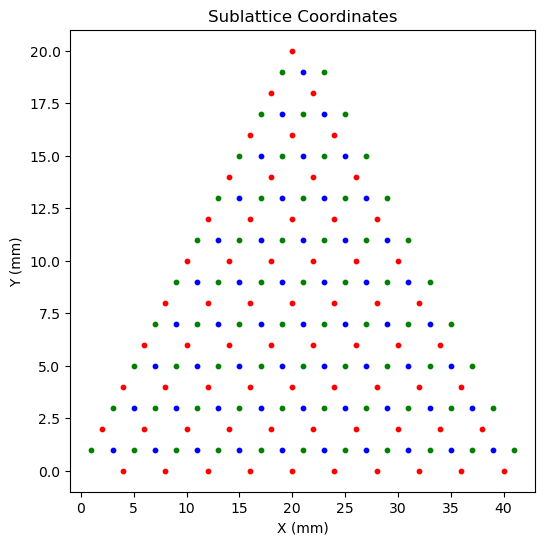

In [33]:
sublat_1_data = np.array(sublat_1_data)
sublat_2_data = np.array(sublat_2_data)
sublat_3_data = np.array(sublat_3_data)

# plot the x and y coordinates of the sublattices
plt.figure(figsize=(6, 6))
plt.scatter(sublat_1_data[:, 0], sublat_1_data[:, 1], c='r', label='Sublattice 1', s=10)
plt.scatter(sublat_2_data[:, 0], sublat_2_data[:, 1], c='g', label='Sublattice 2', s=10)
plt.scatter(sublat_3_data[:, 0], sublat_3_data[:, 1], c='b', label='Sublattice 3', s=10)
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Sublattice Coordinates')

# Frequency response plots

FileNotFoundError: [Errno 2] No such file or directory: '../../../paper_new/band_fig/response_5-5.pdf'

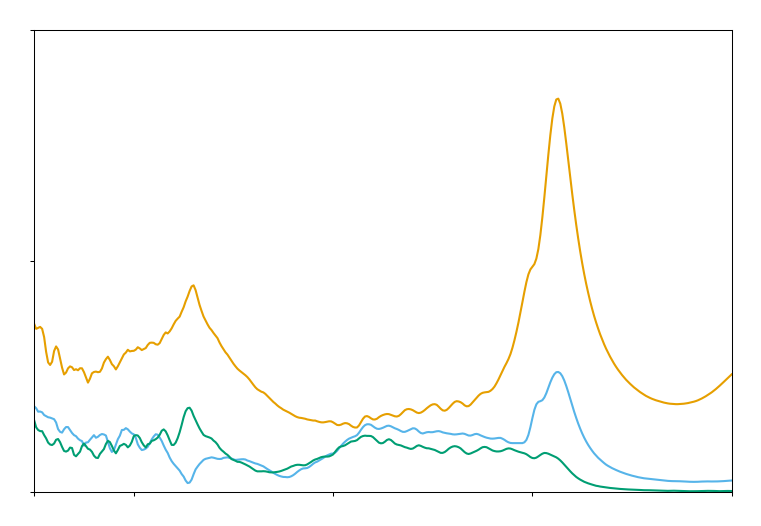

In [8]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

from os import listdir
from os.path import isfile, join

fns = ['scppos_1_1', 'scppos_3_3', 'scppos_5_5']
color = ['#E69F00', '#56B4E9','#009E73']
datadir = '../../../data/kagome-02.26.2022-center/raw/real_space/'
outdir = '../../../paper_new/band_fig/'

preamp_gain = 4.731513 
mic_gain = 0.02 #0.02V/Pa 

plt.figure(figsize=(3,2), dpi=300)
for i, fn in enumerate(fns):
    filepath = datadir+fn+'.pkl'
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
        freq = data[:,0]
        amplitude = data[:,1]
    
    amplitude /= preamp_gain*mic_gain
    

    min_index = np.where(freq == 4000.0)[0][0]
    max_index = np.where(freq == 18000.0)[0][0]
    num = max_index-min_index+1
    
    plt.plot(freq[np.linspace(min_index,max_index,num).astype(int)]/1000, 
             amplitude[np.linspace(min_index,max_index,num).astype(int)],
             color = color[i], linestyle = '-', linewidth = 0.5)
    
        
plt.axis([4, 18, 0, 4])
plt.xticks([4, 6, 10, 14, 18], ['4', '6', '10', '14', '18'])
plt.yticks([0, 2, 4])

ax = plt.gca()
ax.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)


plt.savefig(outdir+'response_'+fn.split('_')[-1]+'-'+fn.split('_')[-2]+'.pdf')



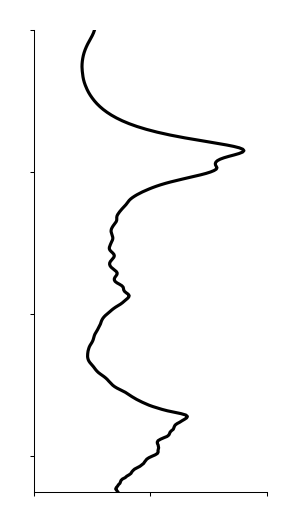

In [ ]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
import matplotlib.cm as cmap

from os import listdir
from os.path import isfile, join
mypath = '../../../data/kagome-02.26.2022-center/raw/avg/'
onlyfiles = [f for f in listdir(mypath) if (isfile(join(mypath, f)) and f != '.DS_Store')]

for i, file in enumerate(onlyfiles):
    with open(join(mypath, file), 'rb') as f:
        data = pickle.load(f)
        if i == 0:
            freq = data[:,0]
            amplitude = data[:,1]
        else:
            amplitude += data[:,1]
        
amplitude /= len(onlyfiles)

preamp_gain = 4.731513 
mic_gain = 0.02 #0.02V/Pa 

amplitude /= preamp_gain*mic_gain


min_index = np.where(freq == 5000.0)[0][0]
max_index = np.where(freq == 18000.0)[0][0]
num = max_index-min_index+1
plt.figure(figsize=(1,2), dpi=300)
plt.plot(amplitude[np.linspace(min_index,max_index,num).astype(int)],
         freq[np.linspace(min_index,max_index,num).astype(int)]/1000,
        'k', linewidth = 0.75)

plt.axis([0, 2, 5, 18])
plt.xticks(np.linspace(0, 2, 3))
plt.yticks(np.linspace(6, 18, 4))

ax = plt.gca()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)

ax.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)
# get rid of the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.savefig("../../../output/paper_new/band_fig/avg_response_plot.pdf")



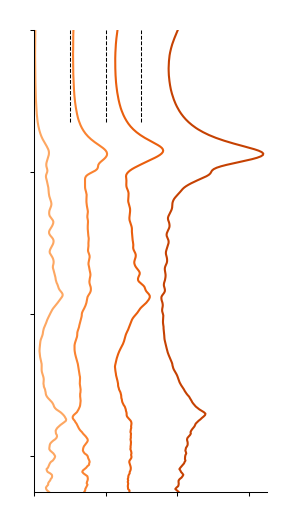

In [18]:
datadir = '../../../data/kagome-02.26.2022-center/raw/real_space/'
line_num = 4
shift = np.linspace(0, 3, line_num)

# Pick 3 colors from the viridis colormap to plot the 3 response curves
color = cmap.Oranges_r(np.linspace(0.2, 0.6, line_num))
fns = [f'scppos_{i}_{i}' for i in range(1, line_num+1)]

plt.figure(figsize=(1,2), dpi=300)

for i, fn in enumerate(fns):
    filepath = datadir+fn+'.pkl'
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
        freq = data[:,0]
        amplitude = data[:,1]
    
    amplitude /= preamp_gain*mic_gain
    

    min_index = np.where(freq == 4000.0)[0][0]
    max_index = np.where(freq == 18000.0)[0][0]
    num = max_index-min_index+1
    
    plt.plot(amplitude[np.linspace(min_index,max_index,num).astype(int)] + shift[line_num-i-1],
             freq[np.linspace(min_index,max_index,num).astype(int)]/1000,
             color = color[i], linestyle = '-', linewidth = 0.5)
    plt.axvline(x=shift[i], ymin=0.8, ymax=1, color='k', linestyle='--', linewidth=0.25)

    

plt.axis([0, 6.5, 5, 18])
plt.xticks(np.linspace(0, 6, 4))
plt.yticks(np.linspace(6, 18, 4))
ax = plt.gca()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)

ax.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)
# get rid of the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig("../../../output/paper_new/band_fig/waterfall_plot.pdf")

In [19]:
# Get the hex code of the colors used in the plot
import matplotlib.cm as cmap
hex_colors = [cmap.colors.to_hex(c) for c in color]
print(hex_colors)

['#c54102', '#e95e0d', '#fa8331', '#fda762']
